In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import eventos

# Variáveis aleatórias Discretas #

Uma variável aleatória discreta é aquela que assume valores em um conjunto discreto $\mathcal{I} = \{x_1,x_2,x_3,...\}$ denominado **espaço amostral da variável**, que pode ser finito ou não. Dada uma variável aleatória discreta $X$, $p_i = P[X=x_i],\,x_i \in \mathcal{I}$ é a probabilidade de $X$ assumir um valor $x_i$ de seu espaço amostral. Para essa mesma variável, sua **média $E[X]$** (também conhecida como esperança) e sua **variância $Var(X)$** são dadas por

$$E[X] = \mu_X = \sum \limits_{-\infty}^{\infty}x_i\cdot P[X=x_i]\,,$$
$$Var(X) = \sigma^2 =  E[(X-\mu_X)^2] = E[X^2] - {E[X]}^2\,.$$

O parâmetro $\sigma = \sqrt{Var(X)}$ é denominado desvio padrão de $X$ e (assim como a variância) informa o quanto se espera que a variável aleatória $X$ se distancie de sua média. O termo $E[X^2]$ é denominado segundo momento da variável $X$ ou, mais frequentemente, de **potência média da variável aleatória $X$**, de modo geral o termo $E[X^n]$ é conhecido como $n$º momento da variável aleatória $X$.

### Distribuição de Bernoulli ###

Variáveis aleatórias de Bernoulli são variáveis aleatórias discretas que podem assumir apenas dois valores: 1, com probabilidade $p$, ou 0, com probabilidade $1-p$. Para denotar que uma variável aleatória $X$ possui essa distribuição de probabilidades utiliza-se $X \sim \operatorname{Bernoulli}(p)$ ($p$ é denominado parâmetro da distribuição).

A média e variância desse tipo de variável aleatória é

$$E[X] = p\,,$$
$$Var(X) = p(1-p)\,.$$

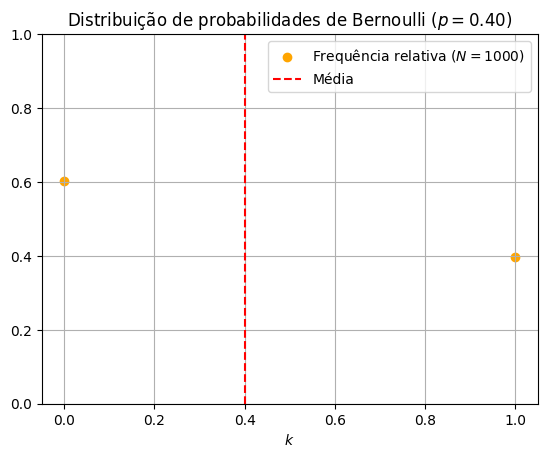

In [ ]:
p = 0.4
k_array = np.array([0,1])

N = 1000
frequencia_relativa = np.zeros(2)
for m in range(0,N,1):
    b = eventos.Bernoulli(p)
    indice = np.where(k_array == b)[0]
    frequencia_relativa[indice] += 1/N

plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($N=%d$)' %N, color = 'orange')
plt.axvline(p, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Distribuição de probabilidades de Bernoulli ($p=%.2f$)' %p)
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.ylim([0,1])
plt.show()

### Distribuição Binomial ###

Uma distribuição binomial de probabilidades é uma distribuição que mede a probabilidade de, em $n$ repetições independentes de uma variável aleatória de Bernoulli de parâmetro $p$, ocorram exatamente $k$ sucessos (resultados 1). Se uma variável aleatória $X$ segue essa distribuição de probabilidades, escreve-se $X \sim \operatorname{Bin}(n,p)$.

Para essa variável aleatória $X$,

$$P[X=k] = \binom{n}{k}p^k (1-p)^{n-k}\,,$$
$$E[X] = n\cdot p\,,$$
$$Var(X) = n\cdot p(1-p)\,.$$

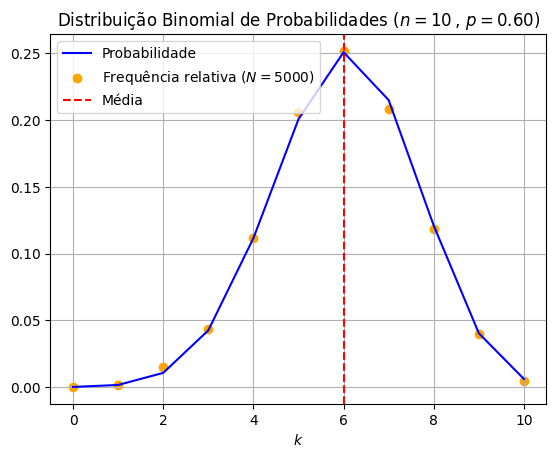

In [ ]:
n = 10 # 10 repetições
p = 0.6 # Probabilidade de sucesso em uma repetição
k_array = np.arange(0,n+1,1)
prob_array = []
for k in k_array:
    prob_array.append(eventos.prob_Bin(n,p,k))
prob_array = np.array(prob_array)

N = 5000
frequencia_relativa = np.zeros_like(prob_array)
for m in range(0,N,1):
    b = eventos.Bin(n,p)
    indice = np.where(k_array == b)[0]
    frequencia_relativa[indice] += 1/N

plt.plot(k_array, prob_array, '-', label = 'Probabilidade', color = 'blue')
plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($N=%d$)' %N, color = 'orange')
plt.axvline(n*p, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Distribuição Binomial de Probabilidades ($n=%d\,,\,p=%.2f$)' %(n,p))
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.show()

### Distribuição geométrica ###

Uma distribuição geométrica de probabilidades mede a probabilidade de um evento de Bernoulli de parâmetro $p$ precisar de exatamente $k$ repetições independentes até obter o primeiro sucesso (resultado 1). Se uma variável aleatória $X$ segue uma distribuição geométrica de probabilidades, escreve-se $X \sim \operatorname{Geom}(p)$.

Para essa variável aleatória $X$,

$$P[X=k]=(1-p)^{k-1}p\,,$$
$$E[X] = \frac{1}{p}\,,$$
$$Var(X)=\frac{1-p}{p^2}\,.$$

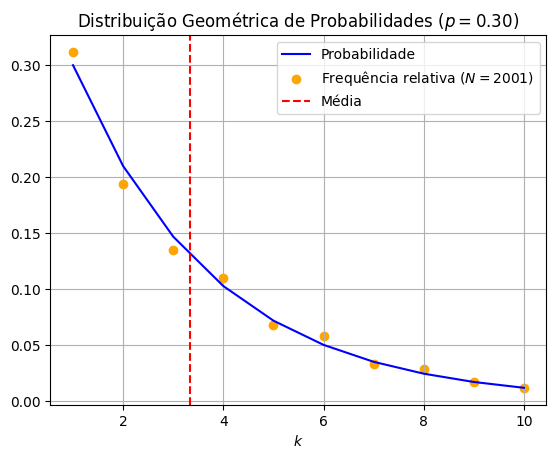

In [ ]:
p = 0.3
if p == 0:
    k_final = 1
else:
    k_final = int(3*(1/p))

k_array = np.arange(1,k_final+1,1)
prob_array = []
for k in k_array:
    prob_array.append(eventos.prob_Geom(p, k))
prob_array = np.array(prob_array)
frequencia_relativa = np.zeros(len(k_array))
N = 2001
for m in range(0,N,1):
    g = eventos.Geom(p)
    indice = np.where(k_array == g)[0]
    frequencia_relativa[indice] += 1/N

plt.plot(k_array, prob_array, '-', label = 'Probabilidade', color = 'blue')
plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($N=%d$)' %N, color = 'orange')
plt.axvline(1/p, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Distribuição Geométrica de Probabilidades ($p=%.2f$)' %(p))
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.show()

### Distribuição de Poisson ###

Uma distribuição de probabilidades de Poisson mede a probabilidade de que, em um determinado intervalo de tempo onde se espera que ocorram $\lambda$ eventos (valores 1 de uma variável aleatória de Bernoulli), ocorram $k$ eventos. Se uma variável aleatória $X$ segue uma distribuição de probabilidades de Poisson, escreve-se $X \sim \operatorname{Poisson}(\lambda)$.

Para essa variável aleatória $X$,

$$P[X=k]=\frac{e^{-\lambda}\cdot\lambda^k}{k!}\,,$$
$$E[X] = \lambda\,,$$
$$Var(X)=\lambda\,.$$

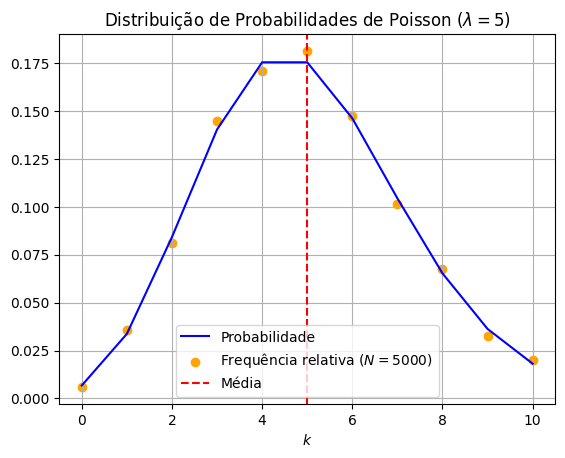

In [ ]:
lambda_ = 5
if lambda_ == 0:
    k_max = 2
else:
    k_max = 2*lambda_

k_array = np.arange(0, k_max+1, 1)
prob_array = []
for k in k_array:
    prob_array.append(eventos.prob_Poisson(lambda_, k))
prob_array = np.array(prob_array)

N = 5000
frequencia_relativa = np.zeros_like(prob_array)
for m in range(0,N,1):
    b = eventos.Poisson(lambda_)
    if b <= k_max:
        indice = np.where(k_array == b)[0]
        frequencia_relativa[indice] += 1/N

plt.plot(k_array, prob_array, label = 'Probabilidade', color = 'blue')
plt.scatter(k_array, frequencia_relativa, label = r'Frequência relativa ($N=%d$)' %N, color = 'orange')
plt.axvline(lambda_, linestyle = '--', color = 'red', label = 'Média')
plt.grid(True)
plt.title(r'Distribuição de Probabilidades de Poisson ($\lambda=%d$)' %lambda_)
plt.legend(loc = 'best')
plt.xlabel(r'$k$')
plt.show()